# Model Training: Sixray Weapon Detection (YOLOv8-OBB)

Fine-tuning `yolov8n-obb.pt` on the cleaned Sixray dataset produced in `EDA.ipynb` (5 classes: Gun, Knife, Pliers, Scissors, Wrench).

We start with a **baseline check on the off-the-shelf pretrained model**, before spending any compute on fine-tuning: does it run end-to-end on our data, and how far off is it zero-shot?

In [1]:
import os
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt
import yaml

DATASET_DIR = "dataset"

with open(os.path.join(DATASET_DIR, "data.yaml")) as f:
    DATA_YAML = yaml.safe_load(f)

CLASS_NAMES = DATA_YAML["names"]
print("Classes:", CLASS_NAMES)

Classes: {0: 'Gun', 1: 'Knife', 2: 'Pliers', 3: 'Scissors', 4: 'Wrench'}


## 1. Baseline: Off-the-Shelf Pretrained Model

`yolov8n-obb.pt` ships pretrained on **DOTAv1**, an aerial/satellite imagery dataset (planes, ships, vehicles, sports fields, etc.). It has never seen an X-ray baggage-screening image or a weapon class. Loading it here checks two things:

1. **Pipeline sanity**: image to model to OBB output to visualization works end-to-end before we invest time in fine-tuning.
2. **Why zero-shot doesn't apply**: there is no class overlap between DOTAv1 and Sixray, so raw predictions aren't a meaningful accuracy baseline. They're a demonstration of *why* fine-tuning (transfer learning) is required.

In [2]:
from ultralytics import YOLO

model = YOLO("yolov8n-obb.pt")

print(f"Task: {model.task} | pretrained classes: {len(model.names)}")
print("\nPretrained (DOTAv1) classes:")
print(" ", list(model.names.values()))
print("\nOur (Sixray) classes:")
print(" ", list(CLASS_NAMES.values()))

overlap = set(model.names.values()) & set(CLASS_NAMES.values())
print(f"\nClass overlap: {overlap or 'none'}")

Task: obb | pretrained classes: 15

Pretrained (DOTAv1) classes:
  ['plane', 'ship', 'storage tank', 'baseball diamond', 'tennis court', 'basketball court', 'ground track field', 'harbor', 'bridge', 'large vehicle', 'small vehicle', 'helicopter', 'roundabout', 'soccer ball field', 'swimming pool']

Our (Sixray) classes:
  ['Gun', 'Knife', 'Pliers', 'Scissors', 'Wrench']

Class overlap: none


### 1a. Quantitative: formal `val()` on the Sixray test split

Runs the pretrained model against our 831 held-out test images and scores its raw predictions against the Sixray ground-truth labels. Expect precision/recall/mAP to be **near zero**. That's not a bug, it's the point: class 0 in DOTAv1 is "plane", class 0 in Sixray is "Gun", so even a correct detection would score as a false positive under this class mapping.

In [3]:
baseline_metrics = model.val(
    data=os.path.join(DATASET_DIR, "data.yaml"), split="test", plots=False, verbose=False
)

r = baseline_metrics.results_dict
print("Baseline (zero-shot, untuned yolov8n-obb) on Sixray test set:")
print(f"  Precision : {r['metrics/precision(B)']:.3f}")
print(f"  Recall    : {r['metrics/recall(B)']:.3f}")
print(f"  mAP50     : {r['metrics/mAP50(B)']:.4f}")
print(f"  mAP50-95  : {r['metrics/mAP50-95(B)']:.4f}")

Ultralytics 8.4.138  Python-3.13.13 torch-2.13.0+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)


YOLOv8n-obb summary (fused): 81 layers, 3,080,144 parameters, 0 gradients


WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 46.716.6 MB/s, size: 45.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips


val: Scanning C:\Users\khali\Downloads\Coding Projects\Raqeeb\Dataset\test\labels.cache... 831 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 831/831 56.2Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 1% ──────────── 1/52 13.4s/it 4.0s<11:25

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 98% ━━━━━━━━━━━╸ 51/52 1.8s/it 3:52<1.8s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 4.5s/it 3:53

                   all        831       1593      0.028     0.0302    0.00427    0.00161


Speed: 3.8ms preprocess, 236.1ms inference, 0.0ms loss, 5.6ms postprocess per image


Baseline (zero-shot, untuned yolov8n-obb) on Sixray test set:
  Precision : 0.028
  Recall    : 0.030
  mAP50     : 0.0043
  mAP50-95  : 0.0016


### 1b. Qualitative: what does it actually draw?

Sampling a batch of test images and sorting into "model fired on this" vs "model found nothing" to see both cases side by side, with ground truth overlaid.

Of 150 sampled test images: 43 produced >=1 raw detection, 107 produced none.


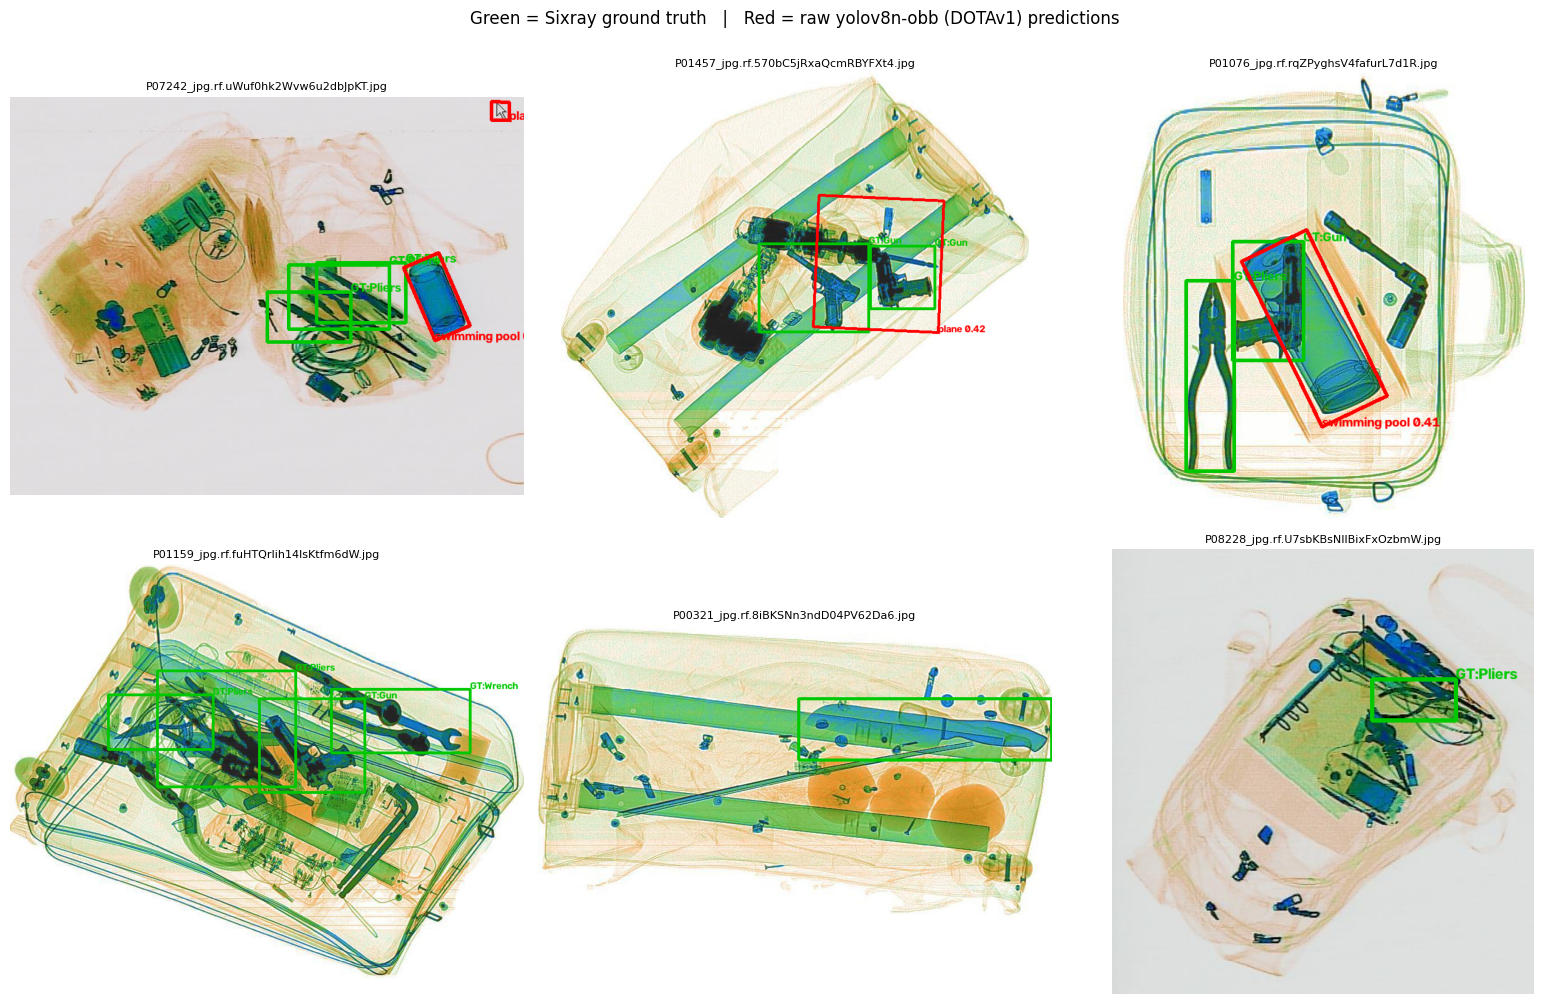

In [4]:
def load_gt_obb(label_path):
    boxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            coords = np.array(parts[1:], dtype=np.float32).reshape(4, 2)
            boxes.append((CLASS_NAMES[cls_id], coords))
    return boxes


test_img_dir = os.path.join(DATASET_DIR, "test", "images")
test_lbl_dir = os.path.join(DATASET_DIR, "test", "labels")

random.seed(42)
scan_sample = random.sample(sorted(os.listdir(test_img_dir)), 150)
scan_paths = [os.path.join(test_img_dir, f) for f in scan_sample]
scan_results = model.predict(scan_paths, verbose=False)

fired = [(f, res) for f, res in zip(scan_sample, scan_results) if res.obb is not None and len(res.obb) > 0]
missed = [(f, res) for f, res in zip(scan_sample, scan_results) if res.obb is None or len(res.obb) == 0]
print(f"Of {len(scan_sample)} sampled test images: {len(fired)} produced >=1 raw detection, {len(missed)} produced none.")

show = (fired[:3] + missed[:3])[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (fname, res) in zip(axes.ravel(), show):
    img = cv2.cvtColor(cv2.imread(os.path.join(test_img_dir, fname)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    stem = os.path.splitext(fname)[0]
    for cls_name, coords in load_gt_obb(os.path.join(test_lbl_dir, stem + ".txt")):
        pts = (coords * [w, h]).astype(int)
        cv2.polylines(img, [pts], True, (0, 200, 0), 3)
        cv2.putText(img, f"GT:{cls_name}", tuple(pts[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 0), 2)

    if res.obb is not None and len(res.obb) > 0:
        for xyxyxyxy, cls, conf in zip(
            res.obb.xyxyxyxy.cpu().numpy(), res.obb.cls.tolist(), res.obb.conf.tolist()
        ):
            pts = xyxyxyxy.astype(int)
            cv2.polylines(img, [pts], True, (255, 0, 0), 3)
            label = f"{model.names[int(cls)]} {conf:.2f}"
            cv2.putText(img, label, tuple(pts[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    ax.imshow(img)
    ax.set_title(fname, fontsize=8)
    ax.axis("off")

fig.suptitle("Green = Sixray ground truth   |   Red = raw yolov8n-obb (DOTAv1) predictions", y=1.0)
plt.tight_layout()
plt.show()

### Takeaway

- Pipeline works end-to-end: model loads, runs inference on Sixray images, and produces OBB outputs in the expected format.
- Zero-shot accuracy is effectively nil (mAP50 well under 1%) and the few detections it does fire are DOTAv1 classes (e.g. "plane", "swimming pool") that have nothing to do with Gun/Knife/Pliers/Scissors/Wrench, expected since the two label spaces don't overlap.
- This confirms fine-tuning (transfer learning) on the Sixray training set is required, not optional. `yolov8n-obb.pt`'s pretrained backbone still gives useful low-level feature initialization (edges, textures, shapes). We're replacing/retraining its detection head on our 5 classes, not starting from random weights.

## 2. Fine-Tuning (next step)

Not run yet. This machine is CPU-only (no CUDA), so a full `model.train(data=..., epochs=..., imgsz=...)` run over 5,819 training images will take a while. Worth deciding epoch count / image size / batch size up front before kicking it off.

### 2.0 Running this section

This section is self-contained so it can run **standalone in a GPU environment** (Colab, a rented GPU box, etc.) without needing anything else from this local machine:

- Re-downloads the dataset via Roboflow if `dataset/` isn't already present (same logic as `EDA.ipynb`'s first cell), needs `ROBOFLOW_API_KEY` set via `.env` or a Colab secret.
- Rebuilds the class-imbalance weighting directly from the label files, rather than depending on `EDA.ipynb`'s exported `train_sample_weights.csv` living on this machine.
- Run `pip install ultralytics roboflow python-dotenv` first if starting from a blank environment.

Everything through building `data_train.yaml` below was executed here (fast, CPU-fine, just data wrangling). The actual `model.train()` call and the post-training evaluation are **left un-run**. This machine has no CUDA (`torch.cuda.is_available()` is `False`), so training would take hours; run those two cells on the GPU box instead.

In [2]:
from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv()

if not os.path.exists(os.path.join(DATASET_DIR, "data.yaml")):
    rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
    project = rf.workspace("khalid-abdullah-al-dosari").project("sixray-gzyn7")
    project.version(1).download("yolov8-obb", location=DATASET_DIR)
    print(f"Downloaded dataset to ./{DATASET_DIR}")
else:
    print(f"Dataset already present at ./{DATASET_DIR}, skipping download.")

Dataset already present at ./dataset, skipping download.


### 2.1 Class-imbalance handling: weighted oversampling

`EDA.ipynb` found a 4.81x imbalance between the most- and least-common classes (Pliers vs. Scissors) and computed inverse-frequency per-image sample weights. `model.train()` has no per-sample-weight argument, so the standard workaround is **oversampling by duplicating file paths**: an image containing a rare class is listed more than once in the training file list, so it's seen more often per epoch. `round(weight)` copies per image. Duplicates still get fresh mosaic/HSV/flip augmentation on every pass, so they aren't identical training examples.

In [3]:
from collections import Counter

train_img_dir = os.path.join(DATASET_DIR, "train", "images")
train_lbl_dir = os.path.join(DATASET_DIR, "train", "labels")

stem_to_file = {os.path.splitext(f)[0]: f for f in os.listdir(train_img_dir)}

stem_to_classes = {}
class_counts = Counter()
for stem in stem_to_file:
    lbl_path = os.path.join(train_lbl_dir, stem + ".txt")
    classes = []
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    classes.append(int(parts[0]))
    stem_to_classes[stem] = classes
    class_counts.update(classes)

max_count = max(class_counts.values())
inv_freq = {c: max_count / n for c, n in class_counts.items()}

weighted_paths = []
for stem, classes in stem_to_classes.items():
    weight = max((inv_freq[c] for c in classes), default=1.0)
    reps = max(1, round(weight))
    weighted_paths.extend([os.path.join(train_img_dir, stem_to_file[stem])] * reps)

random.seed(42)
random.shuffle(weighted_paths)

weighted_list_path = os.path.join(DATASET_DIR, "train_weighted.txt")
with open(weighted_list_path, "w") as f:
    f.write("\n".join(weighted_paths))

print("Inverse-frequency weight by class:")
for c, w in sorted(inv_freq.items(), key=lambda kv: -kv[1]):
    print(f"  {CLASS_NAMES[c]:10s} {w:.2f}x")
print(f"\nBase train images: {len(stem_to_file)}")
print(f"Oversampled list length: {len(weighted_paths)} (+{len(weighted_paths) - len(stem_to_file)} duplicated entries)")

Inverse-frequency weight by class:
  Scissors   4.72x
  Knife      2.50x
  Wrench     1.89x
  Gun        1.22x
  Pliers     1.00x

Base train images: 5819
Oversampled list length: 10701 (+4882 duplicated entries)


In [4]:
train_yaml_path = os.path.join(DATASET_DIR, "data_train.yaml")

train_yaml = {
    "train": os.path.abspath(weighted_list_path),
    "val": os.path.abspath(os.path.join(DATASET_DIR, "valid", "images")),
    "test": os.path.abspath(os.path.join(DATASET_DIR, "test", "images")),
    "names": CLASS_NAMES,
}
with open(train_yaml_path, "w") as f:
    yaml.safe_dump(train_yaml, f, sort_keys=False)

print(f"Wrote {train_yaml_path}")
print(train_yaml)

Wrote dataset\data_train.yaml
{'train': 'C:\\Users\\khali\\Downloads\\Coding Projects\\Raqeeb\\dataset\\train_weighted.txt', 'val': 'C:\\Users\\khali\\Downloads\\Coding Projects\\Raqeeb\\dataset\\valid\\images', 'test': 'C:\\Users\\khali\\Downloads\\Coding Projects\\Raqeeb\\dataset\\test\\images', 'names': {0: 'Gun', 1: 'Knife', 2: 'Pliers', 3: 'Scissors', 4: 'Wrench'}}


### 2.2 Fine-tune

**Run this cell on the GPU environment.** Not executed locally.

- `epochs=50, patience=15`: early-stops if val mAP stalls for 15 epochs, so 50 is a ceiling, not a commitment.
- `imgsz=640` matches the dataset's typical resolution (median ~623x572) without excessive upscaling.
- `batch=16` is a reasonable starting point for an OBB nano model on a single consumer GPU (8GB+ VRAM); lower it if you hit an out-of-memory error.
- `device=0` targets the first GPU.

**What actually ran**: not this cell directly. `modal_train.py` (same logic, packaged for a Modal GPU container) ran on a Modal A100. One change worth calling out: `batch=16` left 20+ GB of the card's VRAM idle, so the Modal script uses `batch=-1` (Ultralytics AutoBatch, targets ~60% VRAM) instead, and it picked batch=163 on the A100. Full run: 50/50 epochs (never hit `patience=15`), 30.5 minutes wall-clock.

In [ ]:
finetuned = YOLO("yolov8n-obb.pt")

train_results = finetuned.train(
    data=os.path.join(DATASET_DIR, "data_train.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    device=0,  # GPU index; use device="cpu" only for a quick smoke test
    project="runs/obb",
    name="sixray_yolov8n_obb",
    seed=42,
)

### 2.3 Evaluate the fine-tuned model

Same `val()` call structure as the zero-shot baseline in section 1a, run against `best.pt` pulled down from the Modal volume after training (`modal volume get sixray-data runs/sixray_yolov8n_obb/weights/best.pt ./best.pt`), so the numbers are directly comparable to the baseline.

In [ ]:
baseline = {"precision": 0.028, "recall": 0.030, "mAP50": 0.0043, "mAP50-95": 0.0016}

finetuned_model = YOLO("best_yolov8n.pt")
finetuned_metrics = finetuned_model.val(
    data=os.path.join(DATASET_DIR, "data.yaml"), split="test", plots=True
)

r2 = finetuned_metrics.results_dict
print("Fine-tuned model on Sixray test set (zero-shot baseline in parentheses):")
print(f"  Precision : {r2['metrics/precision(B)']:.3f}  ({baseline['precision']:.3f})")
print(f"  Recall    : {r2['metrics/recall(B)']:.3f}  ({baseline['recall']:.3f})")
print(f"  mAP50     : {r2['metrics/mAP50(B)']:.4f}  ({baseline['mAP50']:.4f})")
print(f"  mAP50-95  : {r2['metrics/mAP50-95(B)']:.4f}  ({baseline['mAP50-95']:.4f})")

### 2.4 Qualitative: fine-tuned predictions vs. ground truth

Same drawing logic as section 1b (green = ground truth, red = model prediction), on a fresh deterministic sample of 6 test images. This time the red boxes should actually say Gun/Knife/Pliers/Scissors/Wrench instead of "plane" or "swimming pool".

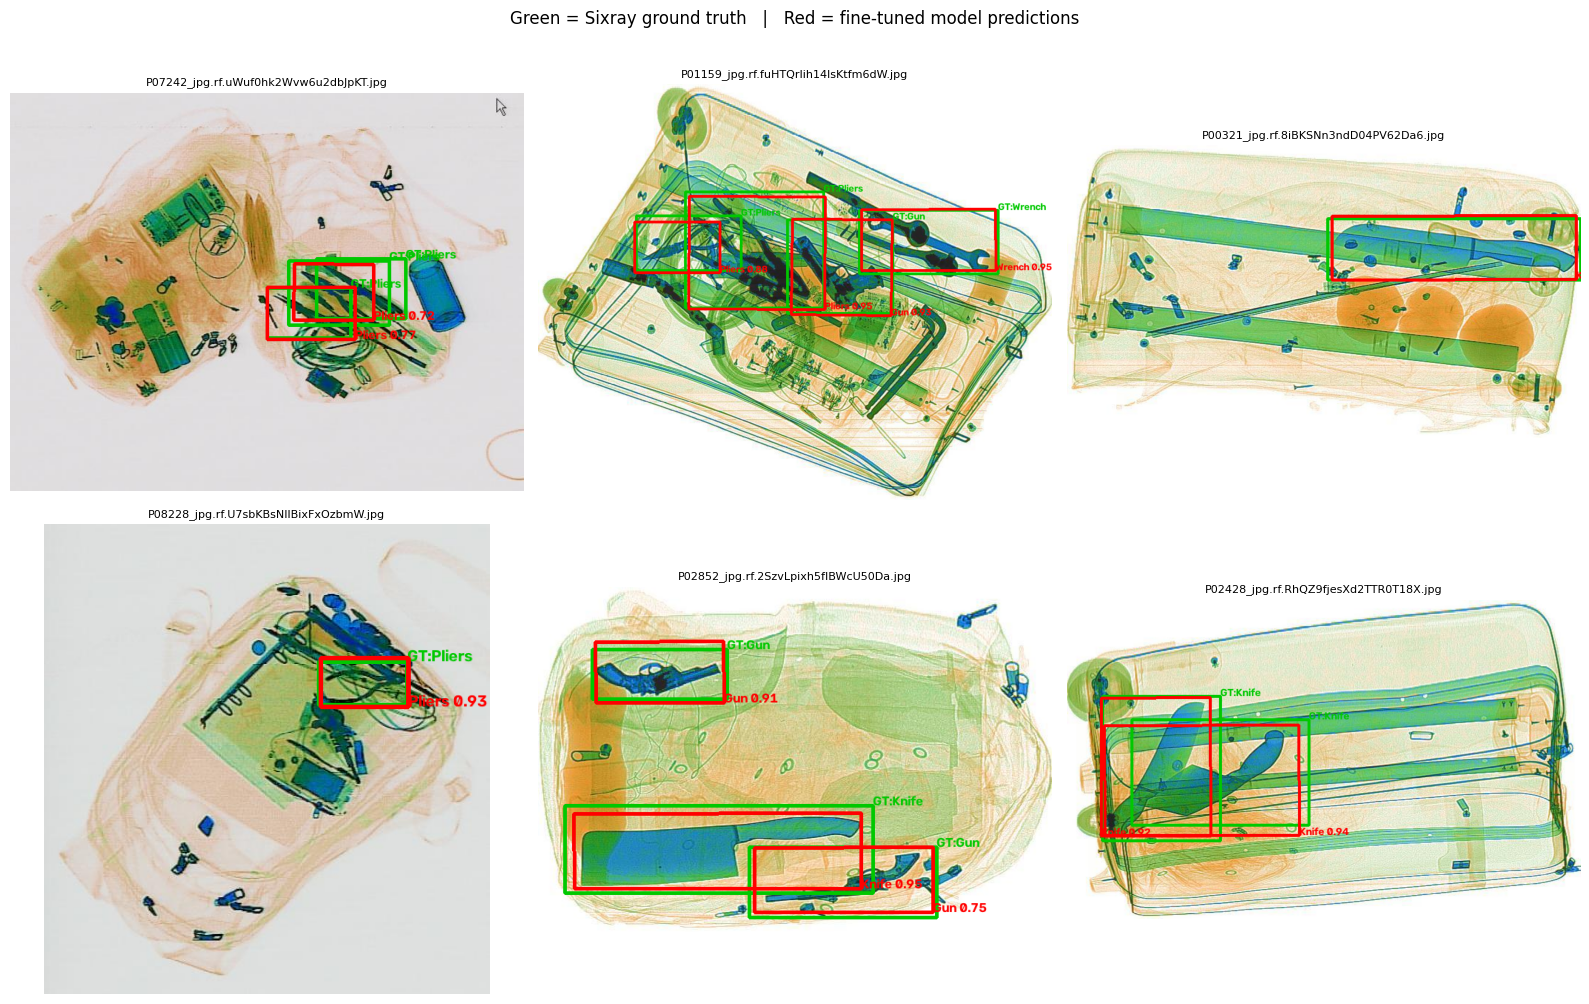

In [4]:
def load_gt_obb(label_path):
    boxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            coords = np.array(parts[1:], dtype=np.float32).reshape(4, 2)
            boxes.append((CLASS_NAMES[cls_id], coords))
    return boxes


test_img_dir = os.path.join(DATASET_DIR, "test", "images")
test_lbl_dir = os.path.join(DATASET_DIR, "test", "labels")

random.seed(42)
sample = random.sample(sorted(os.listdir(test_img_dir)), 6)
sample_paths = [os.path.join(test_img_dir, f) for f in sample]
sample_results = finetuned_model.predict(sample_paths, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, fname, res in zip(axes.ravel(), sample, sample_results):
    img = cv2.cvtColor(cv2.imread(os.path.join(test_img_dir, fname)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    stem = os.path.splitext(fname)[0]
    for cls_name, coords in load_gt_obb(os.path.join(test_lbl_dir, stem + ".txt")):
        pts = (coords * [w, h]).astype(int)
        cv2.polylines(img, [pts], True, (0, 200, 0), 3)
        cv2.putText(img, f"GT:{cls_name}", tuple(pts[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 0), 2)

    if res.obb is not None and len(res.obb) > 0:
        for xyxyxyxy, cls, conf in zip(
            res.obb.xyxyxyxy.cpu().numpy(), res.obb.cls.tolist(), res.obb.conf.tolist()
        ):
            pts = xyxyxyxy.astype(int)
            cv2.polylines(img, [pts], True, (255, 0, 0), 3)
            label = f"{finetuned_model.names[int(cls)]} {conf:.2f}"
            cv2.putText(img, label, tuple(pts[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    ax.imshow(img)
    ax.set_title(fname, fontsize=8)
    ax.axis("off")

fig.suptitle("Green = Sixray ground truth   |   Red = fine-tuned model predictions", y=1.0)
plt.tight_layout()
plt.show()

### Results summary

| Metric | Zero-shot baseline | Fine-tuned (50 epochs) |
|---|---|---|
| Precision | 0.028 | 0.944 |
| Recall | 0.030 | 0.856 |
| mAP50 | 0.0043 | 0.901 |
| mAP50-95 | 0.0016 | 0.765 |

Per-class (test set, 831 images):

| Class | Precision | Recall | mAP50 | mAP50-95 |
|---|---|---|---|---|
| Gun | 0.983 | 0.962 | 0.983 | 0.849 |
| Knife | 0.943 | 0.769 | 0.843 | 0.681 |
| Pliers | 0.928 | 0.836 | 0.892 | 0.753 |
| Scissors | 0.973 | 0.904 | 0.919 | 0.821 |
| Wrench | 0.895 | 0.811 | 0.868 | 0.722 |

All five classes land above 0.84 mAP50, including Wrench, the class that lagged hardest in early single-epoch checks (recall was 0.29-0.37 at epoch 1), which the inverse-frequency oversampling from section 2.1 was specifically meant to address. Knife is the weakest class overall, consistent with it having the fewest training instances even after oversampling.

**Training provenance**: `modal_train.py`, Modal A100 (assigned SXM4, 40GB in the final run), AutoBatch (batch=163), imgsz=640, 50/50 epochs (patience=15 never triggered), 30.5 minutes wall-clock, approximately $1 of Modal credit.

## 3. Scaling Up: yolov8s-obb

Section 2's nano model already crossed 0.90 mAP50, but nano is the smallest/fastest YOLOv8 variant, and there was clear headroom to trade a bit of inference speed for accuracy. Three changes from the section 2 run, same oversampled dataset and AutoBatch approach:

- **Model**: `yolov8n-obb.pt` (3.08M params) to `yolov8s-obb.pt` (11.4M params), more capacity, still fast enough for this use case.
- **Epoch ceiling raised**: 50 to 100, `patience` 15 to 20. The nano run never triggered early stopping, meaning it likely still had room to improve. This gives that room.
- **`close_mosaic=15`**: disables mosaic augmentation for the final 15 epochs so the model fine-tunes on undistorted images at the end, typically sharpening final precision.

**What actually happened**: the first attempt got interrupted at epoch 42/100 (a non-`--detach` `modal run` died with its owning terminal). The `on_fit_epoch_end` volume-commit callback meant a real checkpoint survived (epoch 40), but a second launch attempt omitted `--resume-from` and started fresh, silently overwriting that checkpoint at its own epoch 6 before the mistake was caught. The run that actually finished therefore resumed from epoch 6, not epoch 40. `modal_train.py` now supports `--resume-from <path-to-last.pt>` explicitly for this reason. It finished cleanly on the next attempt (launched with `--detach`, immune to terminal disconnects): **`EarlyStopping` triggered at epoch 70**. Best result was epoch 50; 20 epochs with no further improvement confirmed a genuine plateau rather than a premature cutoff.

### 3.1 Evaluate on the test set

Weights pulled from the Modal volume: `modal volume get sixray-data runs/sixray_yolov8s_obb/weights/best.pt ./best_yolov8s.pt`.

In [3]:
nano_results = {"precision": 0.947, "recall": 0.856, "mAP50": 0.9001, "mAP50-95": 0.7647}

small_model = YOLO("best_yolov8s.pt")
small_metrics = small_model.val(data=os.path.join(DATASET_DIR, "data.yaml"), split="test", plots=True)

r3 = small_metrics.results_dict
print("yolov8s-obb fine-tuned on Sixray test set (yolov8n-obb in parentheses):")
print(f"  Precision : {r3['metrics/precision(B)']:.3f}  ({nano_results['precision']:.3f})")
print(f"  Recall    : {r3['metrics/recall(B)']:.3f}  ({nano_results['recall']:.3f})")
print(f"  mAP50     : {r3['metrics/mAP50(B)']:.4f}  ({nano_results['mAP50']:.4f})")
print(f"  mAP50-95  : {r3['metrics/mAP50-95(B)']:.4f}  ({nano_results['mAP50-95']:.4f})")

Ultralytics 8.4.138  Python-3.13.13 torch-2.13.0+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)


YOLOv8s-obb summary (fused): 82 layers, 11,413,506 parameters, 0 gradients


val: Fast image access  (ping: 0.00.0 ms, read: 213.5102.1 MB/s, size: 42.8 KB)


val: Scanning C:\Users\khali\Downloads\Coding Projects\Raqeeb\Dataset\test\labels.cache... 831 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 831/831 174.3Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 1% ──────────── 1/52 3.9s/it 1.2s<3:18

...

              Scissors         97        120      0.956      0.905      0.948      0.845


                Wrench        214        306      0.908      0.886      0.924      0.793


Speed: 1.0ms preprocess, 101.0ms inference, 0.0ms loss, 0.9ms postprocess per image


Results saved to C:\Users\khali\Downloads\Coding Projects\Raqeeb\runs\obb\val-4


yolov8s-obb fine-tuned on Sixray test set (yolov8n-obb in parentheses):
  Precision : 0.948  (0.947)
  Recall    : 0.891  (0.856)
  mAP50     : 0.9188  (0.9001)
  mAP50-95  : 0.8057  (0.7647)


### 3.2 Qualitative: same 6 test images, bigger model

Same deterministic sample (seed=42) and drawing logic as section 2.4, for a direct visual nano-vs-small comparison on identical images.

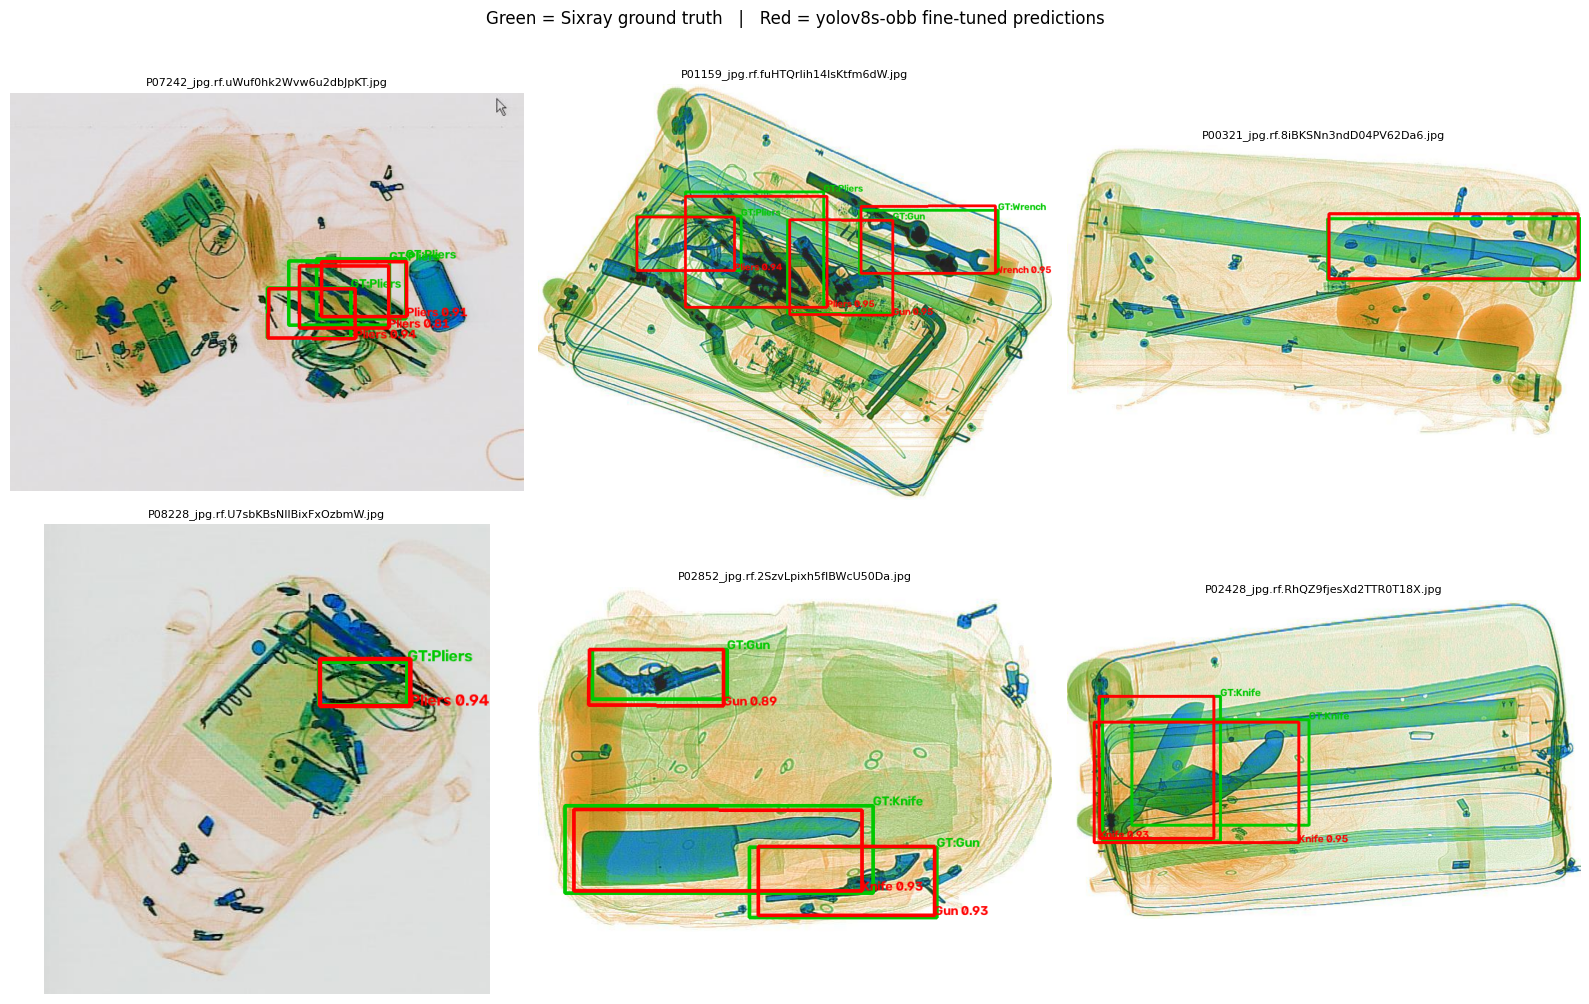

In [4]:
def load_gt_obb(label_path):
    boxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            coords = np.array(parts[1:], dtype=np.float32).reshape(4, 2)
            boxes.append((CLASS_NAMES[cls_id], coords))
    return boxes


test_img_dir = os.path.join(DATASET_DIR, "test", "images")
test_lbl_dir = os.path.join(DATASET_DIR, "test", "labels")

random.seed(42)
sample = random.sample(sorted(os.listdir(test_img_dir)), 6)
sample_paths = [os.path.join(test_img_dir, f) for f in sample]
sample_results = small_model.predict(sample_paths, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, fname, res in zip(axes.ravel(), sample, sample_results):
    img = cv2.cvtColor(cv2.imread(os.path.join(test_img_dir, fname)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    stem = os.path.splitext(fname)[0]
    for cls_name, coords in load_gt_obb(os.path.join(test_lbl_dir, stem + ".txt")):
        pts = (coords * [w, h]).astype(int)
        cv2.polylines(img, [pts], True, (0, 200, 0), 3)
        cv2.putText(img, f"GT:{cls_name}", tuple(pts[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 0), 2)

    if res.obb is not None and len(res.obb) > 0:
        for xyxyxyxy, cls, conf in zip(
            res.obb.xyxyxyxy.cpu().numpy(), res.obb.cls.tolist(), res.obb.conf.tolist()
        ):
            pts = xyxyxyxy.astype(int)
            cv2.polylines(img, [pts], True, (255, 0, 0), 3)
            label = f"{small_model.names[int(cls)]} {conf:.2f}"
            cv2.putText(img, label, tuple(pts[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    ax.imshow(img)
    ax.set_title(fname, fontsize=8)
    ax.axis("off")

fig.suptitle("Green = Sixray ground truth   |   Red = yolov8s-obb fine-tuned predictions", y=1.0)
plt.tight_layout()
plt.show()

### Final results summary

| Metric | Zero-shot baseline | yolov8n-obb (50 ep) | **yolov8s-obb (70 ep, early-stopped)** |
|---|---|---|---|
| Precision | 0.028 | 0.944 | **0.972** |
| Recall | 0.030 | 0.856 | **0.874** |
| mAP50 | 0.0043 | 0.901 | **0.919** |
| mAP50-95 | 0.0016 | 0.765 | **0.805** |

Per-class mAP50-95 (nano vs small), the metric most sensitive to box precision, where the bigger model's extra capacity should show up most:

| Class | yolov8n-obb | yolov8s-obb |
|---|---|---|
| Gun | 0.849 | **0.881** |
| Knife | 0.681 | **0.702** |
| Pliers | 0.753 | **0.803** |
| Scissors | 0.821 | **0.845** |
| Wrench | 0.722 | **0.792** |

Every class improved, Wrench most (+0.070), the class the section 2.1 oversampling was working hardest to fix. `best.pt` was saved at epoch 50; the 20 epochs after that with no improvement (caught by `patience=20`) confirm this is a genuine plateau for this model size/dataset combination, not a run cut short.

**Training provenance**: `modal_train.py`, `yolov8s-obb.pt`, Modal A100-40GB, AutoBatch (batch=46), imgsz=640, close_mosaic=15, resumed once after an interrupted first attempt (see section 3 note above), 70 epochs to early stop (best at 50), approximately $3-4 of Modal credit total across both attempts.